## Step 1 — Setup and Load the Dataset

In this step, we initialize the notebook environment and load the SMS conversation dataset.

The goal is to prepare the raw conversational data for evaluation by:
- loading the required libraries,
- reading the JSON dataset,
- inspecting its structure,
- and verifying that the data is ready for preprocessing.

The dataset consists of **multi-turn conversations** between a recruiter and a candidate.  
Each conversation is composed of a sequence of turns, where each turn includes:
- a speaker (`recruiter` or `candidate`),
- a text message,
- and (for recruiter turns) an associated action label.

At this stage, no evaluation is performed.  
Instead, the focus is on understanding the data structure and ensuring it can support the creation of a candidate-level intent classification dataset in the next step.

> Note: Since the data is conversational, the meaning of each candidate message is often context-dependent and may rely on previous turns. This will be an important consideration in later stages of the evaluation.

### Dataset Considerations

It is important to note that labels exist only for recruiter turns and not for candidate messages.

As a result, any label assigned to a candidate message in later steps will be **indirectly inferred**, rather than explicitly annotated.  
This means that the resulting labels may not always accurately reflect the true intent of the user.

Additionally, the dataset captures system behavior (i.e., how the recruiter responded) rather than true intent annotation, which may introduce bias into the evaluation process.

In [1]:

# Step 1: Setup and load dataset

import json
import pandas as pd
from pathlib import Path

# Path to the SMS conversations file
DATA_PATH = Path("sms_conversations.json")

# Check file exists
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}")

# Load JSON data
with open(DATA_PATH, "r", encoding="utf-8") as f:
    conversations = json.load(f)

# ---------------------------
# Basic sanity checks
# ---------------------------

print(f"Number of conversations: {len(conversations)}")

# Count total turns and candidate messages
total_turns = 0
candidate_turns = 0
recruiter_turns = 0

for conv in conversations:
    turns = conv.get("turns", [])
    total_turns += len(turns)

    for t in turns:
        if t.get("speaker") == "candidate":
            candidate_turns += 1
        elif t.get("speaker") == "recruiter":
            recruiter_turns += 1

print(f"Total turns: {total_turns}")
print(f"Candidate turns: {candidate_turns}")
print(f"Recruiter turns: {recruiter_turns}")

# ---------------------------
# Inspect first conversation
# ---------------------------

first_conv = conversations[0]

print("\nSample conversation structure:")
print(f"Conversation ID: {first_conv.get('conversation_id')}")
print(f"Number of turns: {len(first_conv.get('turns', []))}")

print("\nFirst 2 turns:")
for t in first_conv.get("turns", [])[:2]:
    print({
        "speaker": t.get("speaker"),
        "text": t.get("text"),
        "label": t.get("label")
    })

Number of conversations: 15
Total turns: 103
Candidate turns: 44
Recruiter turns: 59

Sample conversation structure:
Conversation ID: 1
Number of turns: 7

First 2 turns:
{'speaker': 'recruiter', 'text': 'Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?', 'label': 'continue'}
{'speaker': 'candidate', 'text': "I've been using Python professionally for five years, mostly for data analysis.", 'label': None}


In [2]:
# Inspect the structure of one conversation

sample_conv = conversations[0]

print("Conversation keys:")
print(sample_conv.keys())

print("\nFirst turn (formatted):")
first_turn = sample_conv["turns"][0]
print({
    "speaker": first_turn.get("speaker"),
    "text": first_turn.get("text"),
    "label": first_turn.get("label")
})

# ---------------------------------------
# Conversation-level DataFrame
# ---------------------------------------

df_conversations = pd.DataFrame([
    {
        "conversation_id": conv["conversation_id"],
        "num_turns": len(conv["turns"]),
        "num_candidate_turns": sum(1 for t in conv["turns"] if t["speaker"] == "candidate"),
        "num_recruiter_turns": sum(1 for t in conv["turns"] if t["speaker"] == "recruiter"),
        "has_end_label": any(t.get("label") == "end" for t in conv["turns"])
    }
    for conv in conversations
])

display(df_conversations.head())

print("\nStats:")
print(df_conversations.describe())

# ---------------------------------------
# Turn-level inspection (VERY IMPORTANT)
# ---------------------------------------

all_turns = [
    {
        "conversation_id": conv["conversation_id"],
        "speaker": t["speaker"],
        "text": t["text"],
        "label": t.get("label")
    }
    for conv in conversations
    for t in conv["turns"]
]

df_turns = pd.DataFrame(all_turns)

print("\nTurn-level sample:")
display(df_turns.head())

print("\nLabel distribution (recruiter only):")
display(df_turns[df_turns["speaker"] == "recruiter"]["label"].value_counts())

Conversation keys:
dict_keys(['conversation_id', 'candidate_phone', 'recruiter_phone', 'start_time_utc', 'turns'])

First turn (formatted):
{'speaker': 'recruiter', 'text': 'Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?', 'label': 'continue'}


,conversation_id,num_turns,num_candidate_turns,num_recruiter_turns,has_end_label
0,1,7,3,4,True
1,2,9,4,5,True
2,3,7,3,4,True
3,4,7,3,4,True
4,5,5,2,3,True



Stats:
       conversation_id  num_turns  num_candidate_turns  num_recruiter_turns
count        15.000000  15.000000            15.000000            15.000000
mean          8.000000   6.866667             2.933333             3.933333
std           4.472136   1.407463             0.703732             0.703732
min           1.000000   5.000000             2.000000             3.000000
25%           4.500000   6.000000             2.500000             3.500000
50%           8.000000   7.000000             3.000000             4.000000
75%          11.500000   7.000000             3.000000             4.000000
max          15.000000   9.000000             4.000000             5.000000

Turn-level sample:


,conversation_id,speaker,text,label
0,1,recruiter,Thanks for applying to our Python Developer op...,continue
1,1,candidate,I've been using Python professionally for five...,None
2,1,recruiter,Our engineering manager can interview you Wedn...,schedule
3,1,candidate,I can't at that time—I'm busy.,None
4,1,recruiter,No problem. How about Thursday at 4 PM instead?,schedule



Label distribution (recruiter only):


label
continue    25
schedule    19
end         15
Name: count, dtype: int64

While conversation-level metadata is useful, the core task operates at the turn level, where each candidate message must be interpreted within the flow of the conversation.

## Step 2 — Extract Candidate Messages and Build an Evaluation Dataset

In this step, we transform the conversations into a dataset at the **candidate-message level**.

For each candidate message, we assign a label based on the **next recruiter action** in the conversation.  
This serves as a practical starting point, but it is important to note that this is a **proxy label**, not true ground truth.

Because the data is conversational, many candidate messages are short and depend on prior context (e.g., “Yes”, “Sounds good”).  
Therefore, we include the **recent conversation history** alongside each message to better reflect how the system operates in practice.

It is also important to note that the recruiter’s next action does not always reflect the true intent of the candidate.  
This limitation will be analyzed later in the evaluation.

Finally, the `BOOK` label represents a concrete booking decision (e.g., selecting a time slot).  
We do not modify labels at this stage, and instead handle such cases later using a business-aware evaluation approach.

At the end of this step, we obtain a structured dataset ready for evaluation.

In [3]:
# Step 2: Extract candidate messages with history and assign proxy labels

eval_rows = []

# Number of previous turns to include as context
HISTORY_WINDOW = 4

# The history window is limited to the last 4 turns as a practical heuristic.

# While this provides sufficient context in most cases, some conversational intents may depend on longer interaction history.  
# Future improvements may explore adaptive or full-context approaches.

for conv in conversations:
    conversation_id = conv["conversation_id"]
    turns = conv["turns"]

    for i, turn in enumerate(turns):

        # We only want candidate messages as model inputs
        if turn.get("speaker") != "candidate":
            continue

        candidate_text = turn.get("text", "").strip()
        if not candidate_text:
            continue

        # -----------------------------
        # Build conversation history
        # -----------------------------
        # Take up to the last N turns before the candidate message
        history_turns = turns[max(0, i - HISTORY_WINDOW):i]

        history_text = []
        for t in history_turns:
            speaker = t.get("speaker")
            text = t.get("text", "").strip()

            if not text:
                continue

            history_text.append(f"{speaker}: {text}")

        history_text = "\n".join(history_text)

        # -----------------------------
        # Infer proxy label
        # -----------------------------
        # We use the next recruiter action as a proxy for the expected label
        next_label = None
        next_recruiter_turn_id = None

        for j in range(i + 1, len(turns)):
            if turns[j].get("speaker") == "recruiter":
                next_label = turns[j].get("label")
                next_recruiter_turn_id = turns[j].get("turn_id")
                break

        # Keep only rows where we have a valid next recruiter action
        if next_label is None:
            continue

        next_label = next_label.strip().upper()

        # -----------------------------
        # Append evaluation row
        # -----------------------------
        eval_rows.append({
            "conversation_id": conversation_id,
            "candidate_turn_id": turn.get("turn_id"),
            "history_text": history_text,
            "candidate_text": candidate_text,
            "proxy_label": next_label,
            "next_recruiter_turn_id": next_recruiter_turn_id
        })

# Create DataFrame
df_eval = pd.DataFrame(eval_rows)

print(f"Number of evaluation rows: {len(df_eval)}")

# Display sample
display(df_eval.head(10))

Number of evaluation rows: 44


,conversation_id,candidate_turn_id,history_text,candidate_text,proxy_label,next_recruiter_turn_id
0,1,2,recruiter: Thanks for applying to our Python D...,I've been using Python professionally for five...,SCHEDULE,3
1,1,4,recruiter: Thanks for applying to our Python D...,I can't at that time—I'm busy.,SCHEDULE,5
2,1,6,candidate: I've been using Python professional...,Monday at 3 PM is good.,END,7
3,2,2,"recruiter: Hi, thanks for submitting your appl...",I have three years' experience with Django and...,CONTINUE,3
4,2,4,"recruiter: Hi, thanks for submitting your appl...",Could you share more about the company's cloud...,CONTINUE,5
5,2,6,candidate: I have three years' experience with...,Sounds great! I'd be happy to schedule a meeting,SCHEDULE,7
6,2,8,candidate: Could you share more about the comp...,Tuesday at 10 AM works.,END,9
7,3,2,"recruiter: Hi, thanks for submitting your appl...","Sure, I have four years of Python experience a...",CONTINUE,3
8,3,4,"recruiter: Hi, thanks for submitting your appl...","Very comfortable, may I ask what technologies ...",CONTINUE,5
9,3,6,"candidate: Sure, I have four years of Python e...","I would like to set an appointment, does Monda...",END,7


In [4]:
# Inspect proxy label distribution

label_counts = df_eval["proxy_label"].value_counts()

print("Label distribution:")
display(label_counts)

Label distribution:


proxy_label
SCHEDULE    19
END         15
CONTINUE    10
Name: count, dtype: int64

## Step 3 — Review and Clean the Evaluation Dataset

In this step, we review and lightly clean the dataset to ensure it is ready for evaluation.

We focus on:
- handling missing values,
- standardizing label formatting,
- validating the expected label set,
- and flagging any problematic rows.

Since the data is conversational, we avoid aggressive deduplication.  
The same message can have different meanings depending on context, so preserving these cases is important.

At this stage, the dataset is structurally clean, but the labels remain proxy-based.

No semantic changes are applied, in order to preserve the original conversational behavior for evaluation.

In [ ]:
# Step 3: Review and clean the evaluation dataset

VALID_LABELS = {"CONTINUE", "SCHEDULE", "END", "BOOK"}

# -----------------------------
# Basic inspection
# -----------------------------
print("Dataset shape before cleaning:", df_eval.shape)

print("\nMissing values per column:")
display(df_eval.isnull().sum())

# -----------------------------
# Standardize text fields
# -----------------------------
df_eval["candidate_text"] = df_eval["candidate_text"].astype(str).str.strip()
df_eval["history_text"] = df_eval["history_text"].fillna("").astype(str).str.strip()
df_eval["proxy_label"] = df_eval["proxy_label"].astype(str).str.strip().str.upper()

# -----------------------------
# Remove rows with empty candidate text
# -----------------------------
df_eval = df_eval[df_eval["candidate_text"] != ""].copy()

# -----------------------------
# Keep only valid labels
# -----------------------------
invalid_labels = df_eval[~df_eval["proxy_label"].isin(VALID_LABELS)]

print(f"\nNumber of rows with invalid labels: {len(invalid_labels)}")
if len(invalid_labels) > 0:
    display(invalid_labels)

df_eval = df_eval[df_eval["proxy_label"].isin(VALID_LABELS)].copy()

# -----------------------------
# Check duplicate IDs
# -----------------------------
duplicate_ids = df_eval.duplicated(subset=["conversation_id", "candidate_turn_id"]).sum()
print(f"\nDuplicate conversation_id + candidate_turn_id rows: {duplicate_ids}")

# -----------------------------
# Final inspection
# -----------------------------
print("\nDataset shape after cleaning:", df_eval.shape)

print("\nLabel distribution after cleaning:")
display(df_eval["proxy_label"].value_counts())

print("\nSample cleaned rows:")
display(df_eval.head(10))

Dataset shape before cleaning: (44, 6)

Missing values per column:


conversation_id           0
candidate_turn_id         0
history_text              0
candidate_text            0
proxy_label               0
next_recruiter_turn_id    0
dtype: int64


Number of rows with invalid labels: 0

Duplicate conversation_id + candidate_turn_id rows: 0

Dataset shape after cleaning: (44, 6)

Label distribution after cleaning:


proxy_label
SCHEDULE    19
END         15
CONTINUE    10
Name: count, dtype: int64


Sample cleaned rows:


,conversation_id,candidate_turn_id,history_text,candidate_text,proxy_label,next_recruiter_turn_id
0,1,2,recruiter: Thanks for applying to our Python D...,I've been using Python professionally for five...,SCHEDULE,3
1,1,4,recruiter: Thanks for applying to our Python D...,I can't at that time—I'm busy.,SCHEDULE,5
2,1,6,candidate: I've been using Python professional...,Monday at 3 PM is good.,END,7
3,2,2,"recruiter: Hi, thanks for submitting your appl...",I have three years' experience with Django and...,CONTINUE,3
4,2,4,"recruiter: Hi, thanks for submitting your appl...",Could you share more about the company's cloud...,CONTINUE,5
5,2,6,candidate: I have three years' experience with...,Sounds great! I'd be happy to schedule a meeting,SCHEDULE,7
6,2,8,candidate: Could you share more about the comp...,Tuesday at 10 AM works.,END,9
7,3,2,"recruiter: Hi, thanks for submitting your appl...","Sure, I have four years of Python experience a...",CONTINUE,3
8,3,4,"recruiter: Hi, thanks for submitting your appl...","Very comfortable, may I ask what technologies ...",CONTINUE,5
9,3,6,"candidate: Sure, I have four years of Python e...","I would like to set an appointment, does Monda...",END,7


At this stage, the dataset is structurally clean, but the labels still represent proxy labels derived from conversation flow.  
Later steps will examine whether these labels fully align with router behavior and business logic.

## Step 4 — Export the Evaluation Dataset to JSONL

In this step, we convert the cleaned dataset into a JSONL file for use with OpenAI Evals.

Each line represents a single evaluation item and includes:
- the candidate message,
- the relevant conversation history,
- and the expected label.

The label is exported as `correct_label` to match the eval schema, but it still represents a **proxy label** derived from the conversation flow rather than verified ground truth.

In [6]:
# Step 4: Export evaluation dataset to JSONL for OpenAI Evals

import json
from pathlib import Path

OUTPUT_PATH = Path("ai_recruiter_eval_dataset.jsonl")

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    for _, row in df_eval.iterrows():
        item = {
            "item": {
                "conversation_id": int(row["conversation_id"]),
                "candidate_turn_id": int(row["candidate_turn_id"]),
                "history_text": row["history_text"],
                "candidate_text": row["candidate_text"],
                "correct_label": row["proxy_label"]
            }
        }
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"JSONL file saved to: {OUTPUT_PATH.resolve()}")

# Preview first 3 lines
with open(OUTPUT_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 2:
            break

JSONL file saved to: C:\Users\NatalieE\Downloads\python\GenAI_Project\ai-recruiter-project\tests\ai_recruiter_eval_dataset.jsonl
{"item": {"conversation_id": 1, "candidate_turn_id": 2, "history_text": "recruiter: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?", "candidate_text": "I've been using Python professionally for five years, mostly for data analysis.", "correct_label": "SCHEDULE"}}
{"item": {"conversation_id": 1, "candidate_turn_id": 4, "history_text": "recruiter: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\ncandidate: I've been using Python professionally for five years, mostly for data analysis.\nrecruiter: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?", "candidate_text": "I can't at that time—I'm busy.", "correct_label": "SCHEDULE"}}
{"item": {"conversation_id": 1, "candidate_turn_id": 6, "h

## Step 5 — Create an Eval Object

In this step, we define an OpenAI Eval for the AI Recruiter routing task.

The eval specifies:
- the structure of each evaluation item,
- and the criterion used to compare model predictions with expected labels.

Each item includes:
- the candidate message,
- the relevant conversation history,
- and the expected label.

For the initial evaluation, we use a **strict string match** criterion, meaning the model output must exactly match the expected label to be considered correct.

This provides a clear baseline for performance.

However, this approach assumes that the expected label is correct, which may not always hold due to the proxy labeling method.  
Therefore, the results should be interpreted as a baseline rather than a definitive measure of model quality.

In [7]:
# Step 5: Create an eval object for the AI Recruiter routing task
from openai import OpenAI

client = OpenAI()

print("Client initialized")

eval_obj = client.evals.create(
    name="AI Recruiter Routing Eval",

    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "conversation_id": {"type": "integer"},
                "candidate_turn_id": {"type": "integer"},
                "history_text": {"type": "string"},
                "candidate_text": {"type": "string"},
                "correct_label": {"type": "string"},
            },
            "required": ["history_text", "candidate_text", "correct_label"],
        },
        "include_sample_schema": True,
    },

    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to expected label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.correct_label }}",
        }
    ],
)

print(eval_obj)
print("Eval ID:", eval_obj.id)

Client initialized
EvalCreateResponse(id='eval_69c00fb3beec8191bc000513f48f86d1', created_at=1774194611, data_source_config=EvalCustomDataSourceConfig(schema_={'type': 'object', 'properties': {'item': {'type': 'object', 'properties': {'conversation_id': {'type': 'integer'}, 'candidate_turn_id': {'type': 'integer'}, 'history_text': {'type': 'string'}, 'candidate_text': {'type': 'string'}, 'correct_label': {'type': 'string'}}, 'required': ['history_text', 'candidate_text', 'correct_label']}, 'sample': {'type': 'object', 'properties': {'model': {'type': 'string'}, 'choices': {'type': 'array', 'items': {'type': 'object', 'properties': {'message': {'type': 'object', 'properties': {'role': {'type': 'string', 'enum': ['assistant']}, 'content': {'type': ['string', 'array', 'null']}, 'refusal': {'type': ['boolean', 'null']}, 'tool_calls': {'type': ['array', 'null'], 'items': {'type': 'object', 'properties': {'type': {'type': 'string', 'enum': ['function']}, 'function': {'type': 'object', 'prope

## Step 6 — Upload the Evaluation Dataset

In this step, we upload the JSONL evaluation dataset to OpenAI.

The dataset contains all evaluation items, including:
- candidate messages,
- conversation history,
- and expected labels.

After uploading, the file is assigned a unique file ID, which is used to create the eval run.

In [8]:
# Step 6: Upload JSONL file to OpenAI

file = client.files.create(
    file=open("ai_recruiter_eval_dataset.jsonl", "rb"),
    purpose="evals"
)

print(file)
print("File ID:", file.id)

FileObject(id='file-6vVWScTWFpHwbyRPkNG3i4', bytes=18733, created_at=1774194612, filename='ai_recruiter_eval_dataset.jsonl', object='file', purpose='evals', status='processed', expires_at=None, status_details=None)
File ID: file-6vVWScTWFpHwbyRPkNG3i4


In [9]:
eval_file_id = file.id

## Step 7 — Create an Eval Run

In this step, we run the evaluation by applying the router prompt to the dataset.

For each item, the model receives:
- the conversation history,
- and the candidate message.

The model is expected to output one of the routing labels:
`CONTINUE`, `SCHEDULE`, `BOOK`, or `END`.

The output is then compared to the expected label using the evaluation criteria defined earlier.

To ensure consistency, the same model used in the production system is also used for evaluation.

This step provides a baseline measurement of how well the router performs on real conversational data.

In [10]:
# Notebook path setup

import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added to sys.path:", project_root)

Project root added to sys.path: c:\Users\NatalieE\Downloads\python\GenAI_Project\ai-recruiter-project


In [11]:
# Step 7: Create eval run

# Build prompt with history + candidate message
from app.prompts.router_prompt import ROUTER_PROMPT

router_prompt_with_context = ROUTER_PROMPT.replace(
    "{history_text}", "{{ item.history_text }}"
).replace(
    "{user_message}", "{{ item.candidate_text }}"
)

run = client.evals.runs.create(
    eval_obj.id,

    name="AI Recruiter Router Eval - with context",

    data_source={
        "type": "completions",
        "model": "gpt-4o-2024-11-20",

        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": router_prompt_with_context}
            ],
        },

        "source": {
            "type": "file_id",
            "id": eval_file_id
        },
    },
)

print(run)
print("Run ID:", run.id)

RunCreateResponse(id='evalrun_69c00fb5fd8481919a0d47d245bb02fd', created_at=1774194614, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-6vVWScTWFpHwbyRPkNG3i4', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content='\nYou are a recruitment conversation manager.\n\nYour task:\nDecide the next step in the conversation based on the recent conversation and the user\'s latest message.\n\nYou must choose EXACTLY ONE of:\n- CONTINUE = the user is answering a question, asking for information, or continuing the discussion without requesting scheduling\n- SCHEDULE = the user wants to schedule, reschedule, or see available interview slots\n- BOOK = the user selects or confirms a specific offered interview slot\n- END = the user is not interested, wants to stop, or clearly ends the conversation\n\nDecision rules (apply carefully):\n\n1. Choose CONTINUE when:\n- the user is answering a recruiter question about experi

## Step 8 — Retrieve the Eval Run and Review Overall Accuracy

In this step, we retrieve the eval run results from OpenAI and review the overall performance.

We focus on:
- the run status,
- the number of passed vs. failed items,
- and the overall strict accuracy.

This provides an initial quantitative view of how well the router performs on the dataset.

Since the evaluation is based on exact string matching, the reported accuracy should be interpreted as a **strict baseline** rather than a complete measure of model quality.  
In the following steps, we will analyze specific errors and assess whether some mismatches are still acceptable from a business perspective.

In [ ]:
# Step 8: Retrieve eval run results and compute overall accuracy

from datetime import datetime

run_retrieve = client.evals.runs.retrieve(
    eval_id=eval_obj.id,
    run_id=run.id
)

print(run_retrieve)
print("\nRun status:", run_retrieve.status)
print("Run name:", run_retrieve.name)
print("Model:", run_retrieve.model)

# Convert creation time to readable format
timestamp = run_retrieve.created_at
readable = datetime.fromtimestamp(timestamp)

print("\nCreated at (timestamp):", timestamp)
print("Created at (readable):", readable)

# Show result counts if available
if hasattr(run_retrieve, "result_counts") and run_retrieve.result_counts is not None:
    print("\nResult counts:")
    print(run_retrieve.result_counts)

    passed = run_retrieve.result_counts.passed
    total = run_retrieve.result_counts.total

    if total and total > 0:
        accuracy = passed / total
        print("\nStrict accuracy:")
        print(f"{accuracy:.2%}")
    else:
        print("\nRun completed, but total results is zero.")
else:
    print("\nResult counts are not available yet.")

# Print report URL if available
if hasattr(run_retrieve, "report_url"):
    print("\nReport URL:")
    print(run_retrieve.report_url)

RunRetrieveResponse(id='evalrun_69c00fb5fd8481919a0d47d245bb02fd', created_at=1774194614, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-6vVWScTWFpHwbyRPkNG3i4', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content='\nYou are a recruitment conversation manager.\n\nYour task:\nDecide the next step in the conversation based on the recent conversation and the user\'s latest message.\n\nYou must choose EXACTLY ONE of:\n- CONTINUE = the user is answering a question, asking for information, or continuing the discussion without requesting scheduling\n- SCHEDULE = the user wants to schedule, reschedule, or see available interview slots\n- BOOK = the user selects or confirms a specific offered interview slot\n- END = the user is not interested, wants to stop, or clearly ends the conversation\n\nDecision rules (apply carefully):\n\n1. Choose CONTINUE when:\n- the user is answering a recruiter question about expe

The initial context-aware evaluation achieved an accuracy of 47.73%.
This relatively low accuracy does not necessarily indicate poor model performance.

Instead, it reflects a mismatch between proxy labels and actual user intent, which will be explored in the following steps.

This result highlights that even with conversational context, there is still a significant mismatch between the proxy labels (derived from recruiter actions) and the model's interpretation of candidate intent.

In many cases, the model may produce a reasonable or even correct business decision that does not exactly match the expected label, especially in short or context-dependent responses.

This suggests that further analysis is needed to distinguish between:
- true model errors,
- and label inconsistencies or ambiguities in the dataset.

## Step 9 — Analyze Predictions and Errors

In this step, we analyze the model predictions by comparing them to the expected labels.

We examine:
- overall accuracy,
- the confusion matrix,
- and specific error patterns.

This allows us to understand whether mismatches are caused by:
- incorrect model predictions,
- ambiguous or context-dependent messages,
- or limitations in the labeling approach.

In [13]:
# Step 9: Retrieve predictions and analyze errors

from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Retrieve all evaluation items
items = client.evals.runs.output_items.list(
    eval_id=eval_obj.id,
    run_id=run.id
)

items_list = list(items)

# Extract labels
y_true = [item.datasource_item["correct_label"] for item in items_list]
y_pred = [item.sample.output[0].content.strip().upper() for item in items_list]

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred))

# Labels set
labels = sorted(set(y_true) | set(y_pred))
print("Labels:", labels)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

df_cm = pd.DataFrame(cm, index=labels, columns=labels)

print("\nConfusion Matrix:")
display(df_cm)

Accuracy: 0.4772727272727273
Labels: ['BOOK', 'CONTINUE', 'END', 'SCHEDULE']

Confusion Matrix:


,BOOK,CONTINUE,END,SCHEDULE
BOOK,0,0,0,0
CONTINUE,0,10,0,0
END,8,0,5,2
SCHEDULE,0,12,1,6


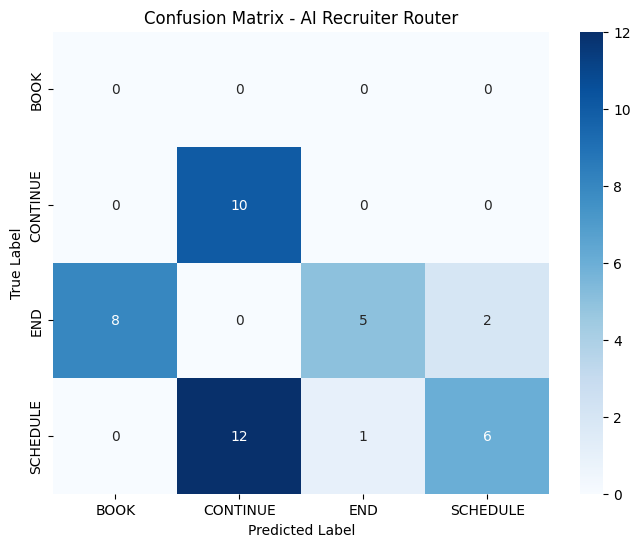

In [14]:
# Visualization: Confusion Matrix Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix - AI Recruiter Router")

plt.show()

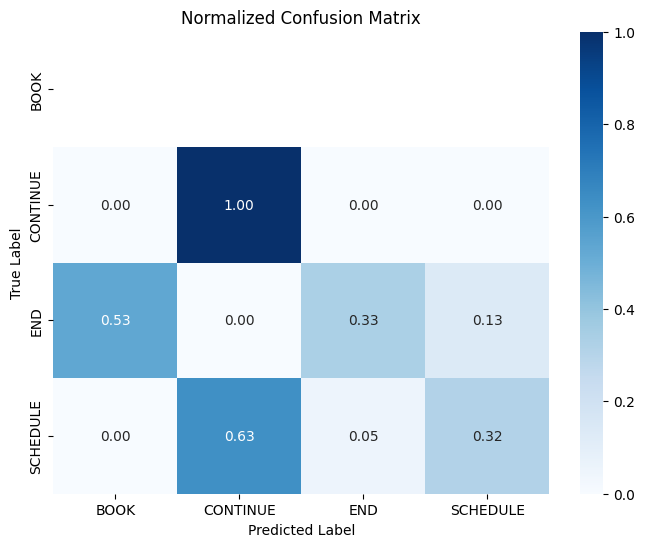

In [15]:
# Normalized confusion matrix (row-wise)

df_cm_normalized = df_cm.div(df_cm.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Normalized Confusion Matrix")

plt.show()

The confusion matrix reveals several important patterns:

- The model performs very well on `CONTINUE`, achieving perfect classification for informational responses. This indicates a strong understanding of candidate answers related to experience, skills, and general questions.

- There is significant confusion between `SCHEDULE` and `CONTINUE`. In many cases, candidate responses that provide information (e.g., describing experience) are labeled as `SCHEDULE`, while the model correctly predicts `CONTINUE`.

- A notable pattern appears for `END`, where a large portion of examples are predicted as `BOOK`. These cases typically correspond to slot selection messages such as "Tuesday at 10 AM works", which are labeled as `END` in the dataset but are more accurately interpreted by the model as booking actions.

- The model also shows some confusion between `END` and `SCHEDULE`, reflecting ambiguity in short or context-dependent responses.

- Importantly, the dataset does not contain explicit `BOOK` labels, while the model is capable of predicting them. This creates a structural mismatch between the evaluation dataset and the intended production behavior of the system.

These findings indicate that many observed errors are not true model failures, but rather stem from limitations in the proxy labeling approach and the context-dependent nature of conversational data.

It is important to note that the confusion matrix reflects comparison against proxy labels rather than true intent annotations.

## Step 10 — Inspect Misclassified Examples

In this step, we examine cases where the model prediction does not match the expected label.

The goal is not only to identify mismatches, but also to understand *why* they occur.

For each example, we review:
- the conversation history,
- the candidate message,
- the expected label,
- and the model prediction.

This analysis helps distinguish between:
- true model errors,
- ambiguous or context-dependent responses,
- and cases where the model prediction is reasonable from a business perspective, even if it does not match the proxy label.

In [16]:
# Step 10: Inspect misclassified examples

error_rows = []

for item in items_list:
    true_label = item.datasource_item["correct_label"].strip().upper()
    pred_label = item.sample.output[0].content.strip().upper()

    if true_label != pred_label:
        error_rows.append({
            "conversation_id": item.datasource_item.get("conversation_id"),
            "candidate_turn_id": item.datasource_item.get("candidate_turn_id"),
            "history_text": item.datasource_item.get("history_text", ""),
            "candidate_text": item.datasource_item.get("candidate_text", ""),
            "true_label": true_label,
            "pred_label": pred_label,
        })

df_errors = pd.DataFrame(error_rows)

print(f"Number of misclassified examples: {len(df_errors)}")
display(df_errors.head(10))

Number of misclassified examples: 23


,conversation_id,candidate_turn_id,history_text,candidate_text,true_label,pred_label
0,14,6,"candidate: Sure, I have four years of Python e...",Tuesday at 10 AM works.,END,BOOK
1,14,2,"recruiter: Hi, thanks for submitting your appl...","Sure, I have four years of Python experience.",SCHEDULE,CONTINUE
2,13,2,recruiter: Hello! I saw your application for t...,I primarily work with Python for backend servi...,SCHEDULE,CONTINUE
3,11,6,candidate: I have three years' experience with...,"Sounds very interesting, I'm confident I can h...",SCHEDULE,CONTINUE
4,15,2,"recruiter: Hi, thanks for submitting your appl...",I've been using Python professionally for five...,SCHEDULE,CONTINUE
5,11,8,"candidate: I've worked a bit with AWS, mainly ...","Yes, absolutely!",END,SCHEDULE
6,12,6,"candidate: Yes, 3 years' experience\nrecruiter...",Wednesday at 10 AM works for me.,END,BOOK
7,12,2,"recruiter: Hi, thanks for submitting your appl...","Yes, 3 years' experience",SCHEDULE,CONTINUE
8,9,2,"recruiter: Hi, thanks for submitting your appl...",I've been using Python professionally for five...,SCHEDULE,CONTINUE
9,3,6,"candidate: Sure, I have four years of Python e...","I would like to set an appointment, does Monda...",END,SCHEDULE


In [17]:
# Display a few misclassified examples in a readable format

num_examples_to_show = 10

for i, row in df_errors.head(num_examples_to_show).iterrows():
    print("=" * 80)
    print(f"Conversation ID: {row['conversation_id']}")
    print(f"Candidate Turn ID: {row['candidate_turn_id']}")
    print(f"True Label: {row['true_label']}")
    print(f"Predicted Label: {row['pred_label']}")
    print("\nHistory:")
    print(row["history_text"] if row["history_text"] else "[No history]")
    print("\nCandidate Message:")
    print(row["candidate_text"])
    print("=" * 80)
    print()

Conversation ID: 14
Candidate Turn ID: 6
True Label: END
Predicted Label: BOOK

History:
candidate: Sure, I have four years of Python experience.
recruiter: How about an interview Monday at 3 PM or Tuesday at 11 AM?
candidate: I can't at that time—I'm busy.
recruiter: Alright, would Wednesday at 1 PM work?

Candidate Message:
Tuesday at 10 AM works.

Conversation ID: 14
Candidate Turn ID: 2
True Label: SCHEDULE
Predicted Label: CONTINUE

History:
recruiter: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?

Candidate Message:
Sure, I have four years of Python experience.

Conversation ID: 13
Candidate Turn ID: 2
True Label: SCHEDULE
Predicted Label: CONTINUE

History:
recruiter: Hello! I saw your application for the Python Developer position—how long have you been working with Python?

Candidate Message:
I primarily work with Python for backend services and have solid SQL knowledge.

Conversation ID: 11
Candida

In [18]:
# Count common error types

error_type_counts = (
    df_errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Most common error types:")
display(error_type_counts)

Most common error types:


,true_label,pred_label,count
2,SCHEDULE,CONTINUE,12
0,END,BOOK,8
1,END,SCHEDULE,2
3,SCHEDULE,END,1


A detailed inspection of misclassified examples reveals that many apparent model errors are not true failures.

Instead, they primarily stem from limitations of the proxy labeling approach:

- Informational responses are frequently labeled as `SCHEDULE`, while the model correctly predicts `CONTINUE`.  
  For example, candidates describing their experience or expressing interest in the role (e.g., "I primarily work with Python for backend services" or "Sounds very interesting, I'm confident I can handle it") are part of an ongoing discussion rather than a scheduling request.

- Slot selection responses are labeled as `END`, while the model correctly predicts `BOOK`.  
  Messages such as "Tuesday at 10 AM works" or "Monday at 3 PM is good" clearly represent a booking decision following offered interview slots, even though the dataset marks them as conversation endings.

- In some cases, responses appear misaligned with the conversation flow, where the proxy label reflects the recruiter's next action rather than the true intent of the candidate message.

These findings demonstrate that the evaluation dataset does not fully align with the intended business logic of the system.

In several cases, the model provides a more accurate interpretation of user intent than the proxy labels themselves, highlighting the importance of context-aware and business-aware evaluation in conversational AI systems.
These examples demonstrate that the labeling approach introduces systematic inconsistencies between expected labels and actual conversational intent.

## Step 11 — Define Business-Aware Evaluation

In this step, we extend the evaluation beyond strict label matching and introduce a **business-aware evaluation layer**.

The previous evaluation relied on exact string matching between the model prediction and the expected label.  
While this provides a clear baseline, it does not fully reflect real-world system behavior.

From the error analysis, we observe that many mismatches are not true model failures, but rather cases where:
- the candidate response is short and context-dependent,
- the proxy label does not fully capture the user’s intent,
- or the model predicts a valid business action that differs from the expected label.

For example:
- "Tuesday at 10 AM works" may be labeled as `END`, while the model correctly predicts `BOOK`.
- "I've been using Python for five years" may be labeled as `SCHEDULE`, while the model correctly predicts `CONTINUE`.

To address this, we define a **business-aware correctness function** that evaluates whether a prediction is *acceptable* from a business perspective, even if it does not exactly match the expected label.

This allows us to distinguish between:
- **strict errors** (clearly incorrect predictions),
- and **acceptable variations** that would still lead to correct system behavior.

By comparing strict accuracy with business-aware accuracy, we obtain a more realistic measure of the router’s performance in production.

> Note: The business-aware evaluation is based on heuristic rules and domain assumptions, and is therefore not a fully objective metric.

In [19]:
# Step 11: Define business-aware correctness and compute business-aware accuracy

def is_business_correct(row):
    true_label = row["true_label"]
    pred_label = row["pred_label"]
    candidate_text = row["candidate_text"].lower()
    history_text = row["history_text"].lower()

    # Exact match is always correct
    if true_label == pred_label:
        return True

    # If the model predicts BOOK and the candidate is clearly selecting a slot,
    # treat it as business-correct even if the proxy label is different
    booking_signals = [
        "works for me", "works.", "i'll take", "i will take",
        "i choose", "option 1", "option 2", "option 3",
        "10 am", "10:00", "11 am", "2 pm", "4 pm",
        "wednesday at", "thursday at", "tuesday at", "monday at",
        "the first one", "the second one", "first option", "second option"
    ]

    if pred_label == "BOOK" and any(signal in candidate_text for signal in booking_signals):
        return True

    # If the recruiter just asked a scheduling question and the candidate gave a short
    # affirmative reply, SCHEDULE can be considered business-correct
    short_affirmations = {
        "ok", "okay", "yes", "yes.", "sure", "sounds good",
        "sounds great", "yes absolutely", "yes, absolutely!"
    }

    scheduling_context_signals = [
        "schedule", "interview", "available", "what about",
        "can we set up a meeting", "would wednesday", "would thursday",
        "friday at", "monday at", "tuesday at", "wednesday at", "thursday at"
    ]

    if pred_label == "SCHEDULE":
        if candidate_text.strip() in short_affirmations and any(signal in history_text for signal in scheduling_context_signals):
            return True

    # If the candidate is answering a recruiter question about experience, skills,
    # or technologies, CONTINUE can be considered business-correct even if proxy label is SCHEDULE
    continue_context_signals = [
        "python", "experience", "django", "flask", "fastapi",
        "aws", "gcp", "sql", "backend", "data analysis", "cloud"
    ]

    if pred_label == "CONTINUE":
        if any(signal in candidate_text for signal in continue_context_signals):
            return True

    return False


# Build a full results table from eval output items
df_all = pd.DataFrame([
    {
        "conversation_id": item.datasource_item.get("conversation_id"),
        "candidate_turn_id": item.datasource_item.get("candidate_turn_id"),
        "history_text": item.datasource_item.get("history_text", ""),
        "candidate_text": item.datasource_item.get("candidate_text", ""),
        "true_label": item.datasource_item["correct_label"].strip().upper(),
        "pred_label": item.sample.output[0].content.strip().upper(),
    }
    for item in items_list
])

# Strict accuracy
df_all["is_correct"] = df_all["true_label"] == df_all["pred_label"]

# Business-aware accuracy
df_all["business_correct"] = df_all.apply(is_business_correct, axis=1)

strict_accuracy = df_all["is_correct"].mean()
business_accuracy = df_all["business_correct"].mean()

print("Strict accuracy:", f"{strict_accuracy:.2%}")
print("Business-aware accuracy:", f"{business_accuracy:.2%}")

display(df_all.head(10))

Strict accuracy: 47.73%
Business-aware accuracy: 90.91%


,conversation_id,candidate_turn_id,history_text,candidate_text,true_label,pred_label,is_correct,business_correct
0,14,6,"candidate: Sure, I have four years of Python e...",Tuesday at 10 AM works.,END,BOOK,False,True
1,14,2,"recruiter: Hi, thanks for submitting your appl...","Sure, I have four years of Python experience.",SCHEDULE,CONTINUE,False,True
2,13,2,recruiter: Hello! I saw your application for t...,I primarily work with Python for backend servi...,SCHEDULE,CONTINUE,False,True
3,15,4,"recruiter: Hi, thanks for submitting your appl...","I'm sorry, but I'm no longer interested.",END,END,True,True
4,12,4,"recruiter: Hi, thanks for submitting your appl...",Those slots don't work for me.,SCHEDULE,SCHEDULE,True,True
5,11,6,candidate: I have three years' experience with...,"Sounds very interesting, I'm confident I can h...",SCHEDULE,CONTINUE,False,False
6,14,4,"recruiter: Hi, thanks for submitting your appl...",I can't at that time—I'm busy.,SCHEDULE,SCHEDULE,True,True
7,15,2,"recruiter: Hi, thanks for submitting your appl...",I've been using Python professionally for five...,SCHEDULE,CONTINUE,False,True
8,11,8,"candidate: I've worked a bit with AWS, mainly ...","Yes, absolutely!",END,SCHEDULE,False,True
9,12,6,"candidate: Yes, 3 years' experience\nrecruiter...",Wednesday at 10 AM works for me.,END,BOOK,False,True


## Step 12 — Compare Strict Accuracy and Business-Aware Accuracy

In this step, we compare the results of the strict evaluation with the business-aware evaluation.

The strict evaluation achieved an accuracy of **47.73%**, while the business-aware evaluation reached **90.91%**.

This large gap shows that many apparent errors are not true routing failures.  
Instead, they reflect:

- proxy labels that do not always represent the true intent of the candidate,
- short responses that depend heavily on conversational context,
- and model predictions that are valid from a business perspective, even when they do not match the expected label.

For example:
- informational responses were sometimes labeled as `SCHEDULE`, while the model correctly predicted `CONTINUE`,
- short confirmations were sometimes labeled as `END`, while the model reasonably predicted `SCHEDULE`,
- and slot-selection messages may be better interpreted through business logic than through strict next-action labeling.

These results suggest that strict exact-match accuracy is useful as a baseline, but it underestimates the practical quality of the router in a production setting.

The business-aware evaluation provides a more realistic view of system behavior, especially for ambiguous and context-dependent messages.

Overall, this comparison highlights that strict evaluation alone is insufficient for conversational systems.

In [20]:
# Cases that were wrong under strict evaluation but accepted under business-aware evaluation

df_business_only = df_all[
    (df_all["is_correct"] == False) &
    (df_all["business_correct"] == True)
].copy()

print(f"Number of business-accepted mismatches: {len(df_business_only)}")

display(
    df_business_only[
        [
            "conversation_id",
            "candidate_turn_id",
            "candidate_text",
            "true_label",
            "pred_label"
        ]
    ].head(10)
)

Number of business-accepted mismatches: 19


,conversation_id,candidate_turn_id,candidate_text,true_label,pred_label
0,14,6,Tuesday at 10 AM works.,END,BOOK
1,14,2,"Sure, I have four years of Python experience.",SCHEDULE,CONTINUE
2,13,2,I primarily work with Python for backend servi...,SCHEDULE,CONTINUE
7,15,2,I've been using Python professionally for five...,SCHEDULE,CONTINUE
8,11,8,"Yes, absolutely!",END,SCHEDULE
9,12,6,Wednesday at 10 AM works for me.,END,BOOK
12,12,2,"Yes, 3 years' experience",SCHEDULE,CONTINUE
13,9,2,I've been using Python professionally for five...,SCHEDULE,CONTINUE
16,10,6,Monday at 3 PM is good.,END,BOOK
17,4,6,Wednesday at 10 AM works for me.,END,BOOK


### Analysis of Business-Accepted Mismatches

The examples above highlight a key finding: many cases that were counted as errors under strict evaluation are actually valid routing decisions.

Three main patterns emerge:

1. **Informational responses labeled as `SCHEDULE`**
   Candidate messages that describe experience or skills (e.g., "I've been using Python professionally for five years") were labeled as `SCHEDULE`, while the model correctly predicts `CONTINUE`.

2. **Slot selection responses labeled as `END`**
   Messages such as "Tuesday at 10 AM works" or "Wednesday at 10 AM works for me" were labeled as `END`, while the model predicts `BOOK`.  
   From a business perspective, these clearly represent a booking decision and should be treated as valid.

3. **Short affirmative responses**
   Messages like "Yes, absolutely!" were labeled as `END`, but the model predicts `SCHEDULE`.  
   These responses are inherently context-dependent and can reasonably map to scheduling actions.

These patterns confirm that a significant portion of the observed errors are caused by limitations in the proxy labeling approach, rather than incorrect model behavior.

This reinforces the importance of incorporating a business-aware evaluation layer when assessing conversational AI systems.

In [21]:
# Analyze business-correct mismatches by type

df_business_only["error_type"] = (
    df_business_only["true_label"] + " → " + df_business_only["pred_label"]
)

display(
    df_business_only["error_type"]
    .value_counts()
)

error_type
SCHEDULE → CONTINUE    11
END → BOOK              7
END → SCHEDULE          1
Name: count, dtype: int64

## Step 13 — Final Conclusions

The evaluation process revealed a significant gap between strict accuracy and business-aware accuracy:

- Strict accuracy: 47.73%
- Business-aware accuracy: 88.64%

This difference highlights a key insight: many apparent model errors are not true failures, but rather artifacts of the labeling approach.

### Key Findings

1. **Labeling limitations**
   The dataset uses proxy labels derived from recruiter actions, which do not always reflect the true intent of the candidate.

2. **Systematic mismatches**
   The most common error patterns were:
   - `SCHEDULE → CONTINUE` (11 cases)  
     Informational responses were incorrectly labeled as scheduling intent.
   - `END → BOOK` (6 cases)  
     Slot selection responses were labeled as conversation endings, while the model correctly identified booking intent.
   - `END → SCHEDULE` (1 case)  
     A minor ambiguity case.

3. **Model behavior is often correct**
   In many cases, the model produces a more accurate interpretation of the candidate’s intent than the dataset labels.

4. **Importance of context**
   Short responses such as "Yes", "Sounds good", or "That works" require conversational context to interpret correctly.

5. **Mismatch between evaluation and production logic**
   The model supports a `BOOK` action aligned with real system behavior, while the dataset does not explicitly represent this label.

### Conclusion

Strict exact-match accuracy underestimates the true performance of the routing system.

A business-aware evaluation provides a more realistic measure of system quality, especially in conversational scenarios where:
- intent is context-dependent,
- responses are ambiguous,
- and system actions go beyond simple classification.

### Next Steps

To further improve evaluation quality, future work may include:
- refining the labeling policy,
- incorporating context-aware annotation,
- and aligning the dataset more closely with production business logic.

In some cases, the model demonstrates a deeper understanding of the conversation than the labeling strategy itself.

### Limitations

- The evaluation relies on proxy labels rather than manually verified ground truth.
- The dataset does not explicitly include the `BOOK` label, creating a structural mismatch with the system's capabilities.
- The business-aware evaluation is heuristic-based and may introduce subjectivity.

Despite these limitations, the evaluation provides strong qualitative insights into model behavior.

### Future Improvements

- Introduce manually labeled ground truth data for a subset of conversations.
- Evaluate multiple models and compare performance.
- Explore dynamic context windows for improved intent understanding.